# Aula 4

![](../../data/imagem/banner-pos-2022.jpg)

# Feature Maps

### Objetivo

Este material, tem o objetivo de **visualizar e interpretar os mapas de ativação (features maps)** gerados pelas camadas convolucionais de um modelo de classificação de imagens. Através da exibição gráfica dessas ativações, é possível entender **quais padrões visuais** (bordas, texturas, formas) são aprendidas em diferentes profundidades da rede neural, facilitando a análise interpretável do comportamento interno do modelo e auxiliando no diagnóstico de seu funcionamento. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model, model_from_json

2025-07-21 15:46:04.602644: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753123565.346540  209830 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753123565.561449  209830 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753123567.649776  209830 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753123567.649846  209830 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753123567.649855  209830 computation_placer.cc:177] computation placer alr

In [2]:
def load_model(name_model, path='model',
               compile_model=True, compile_args=None):
    """
    Carrega um modelo salvo em JSON + pesos .weights.h5.
    Opcionalmente compila o modelo ao carregar.
    """
    # Carrega arquitetura
    with open(f'{path}/{name_model}.json', 'r') as json_file:
        loaded_model_json = json_file.read()

    loaded_model = model_from_json(loaded_model_json)

    # Carrega pesos
    weights_path = f"{path}/{name_model}.weights.h5"
    loaded_model.load_weights(weights_path)

    print(f"✅ Modelo '{name_model}' carregado com sucesso.")

    # Compila se solicitado
    if compile_model:
        compile_args = compile_args or {
            'optimizer': 'adam',
            'loss': 'sparse_categorical_crossentropy',
            'metrics': ['accuracy']
        }
        loaded_model.compile(**compile_args)
        print("🔧 Modelo compilado.")

    return loaded_model

In [3]:
compile_args = {
    'optimizer': tf.keras.optimizers.Adam(learning_rate=0.0001),
    'loss': 'sparse_categorical_crossentropy',
    'metrics': ['accuracy']
}

model = load_model(
    name_model = 'model_v01',
    path = 'models',
    compile_model = True,
    compile_args = compile_args
)

2025-07-21 15:46:45.114173: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ Modelo 'model_v01' carregado com sucesso.
🔧 Modelo compilado.


In [4]:
model.summary()

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,586 (721.04 KB)

 Trainable params: 184,586 (721.04 KB)

 Non-trainable params: 0 (0.00 B)

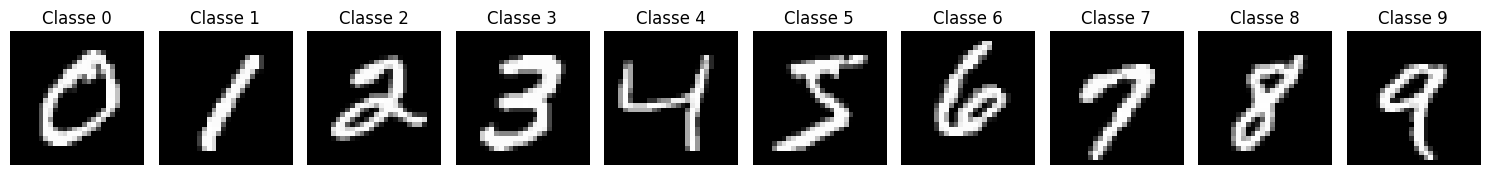

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

classes = np.unique(y_train)
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, cls in enumerate(classes):
    idx = np.where(y_train == cls)[0][0]
    axes[i].imshow(x_train[idx], cmap='gray')
    axes[i].set_title(f'Classe {cls}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
def preprocess_image(image):
    image = image / 255
    image = np.expand_dims(image, axis=0)
    return image

In [7]:
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name or 'expanded_conv' in layer.name]
activation_model = Model(inputs=model.layers[0].input, outputs=layer_outputs)

activation_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 24, 24,    │        832 │ input_layer[0][0… │
│                     │ 32)               │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 12, 12,    │          0 │ conv1[2][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 8, 8, 64)  │     51,264 │ pool1[1][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,096 (203.50 KB)

 Trainable params: 52,096 (203.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
def display_feature_maps(feature_maps, layer_names, max_layers=5, max_features=8):
    for i in range(min(len(feature_maps), max_layers)):
        fmap = feature_maps[i]
        layer_name = layer_names[i]
        num_features = min(fmap.shape[-1], max_features)

        size = fmap.shape[1]
        display_grip = np.zeros((size, size * num_features))

        for j in range(num_features):
            channel_image = fmap[0, :, :, j]
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std() + 1e-5
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grip[:, j*size: (j+1)*size] = channel_image
        
        scale = 1. / size
        plt.figure(figsize=(scale * display_grip.shape[1], scale * display_grip.shape[0]))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grip, aspect='auto', cmap='viridis')
        plt.axis('off')
        plt.show()

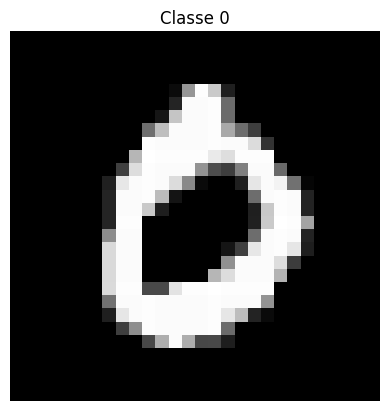

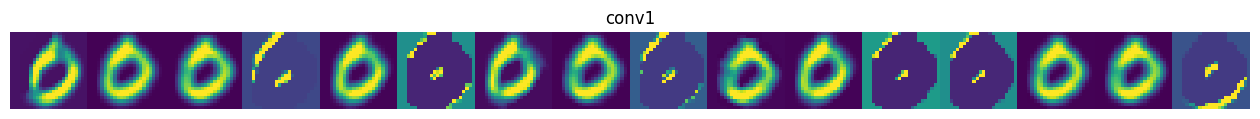

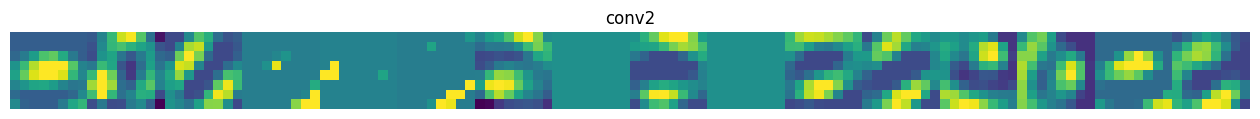

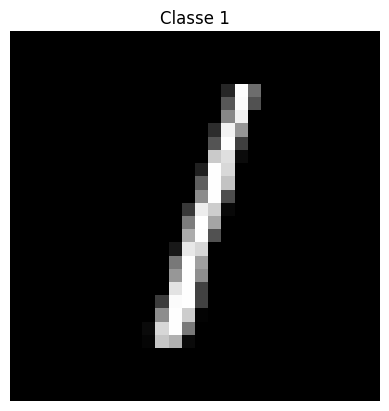

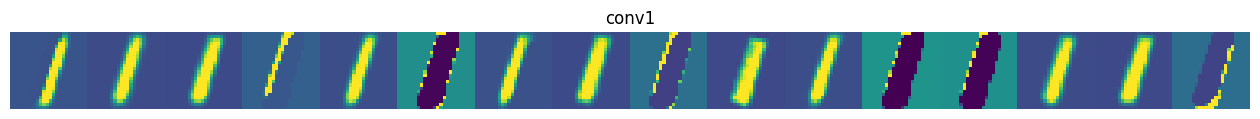

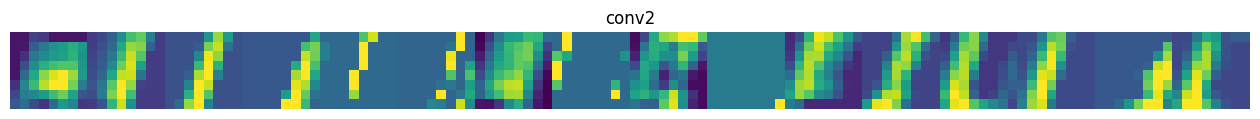

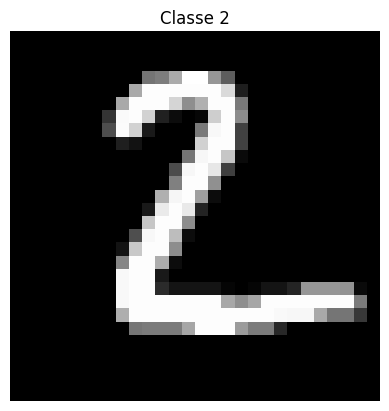

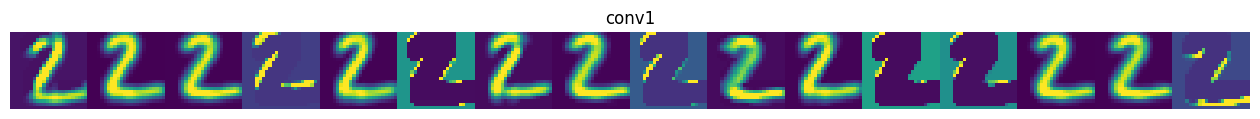

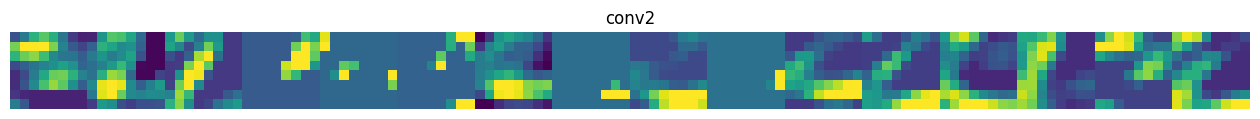

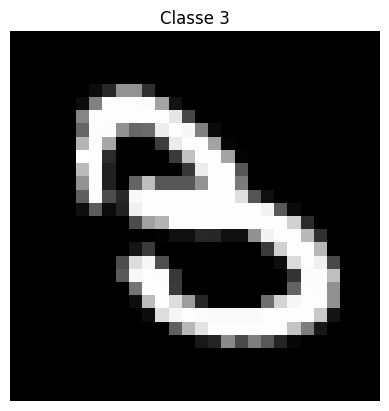

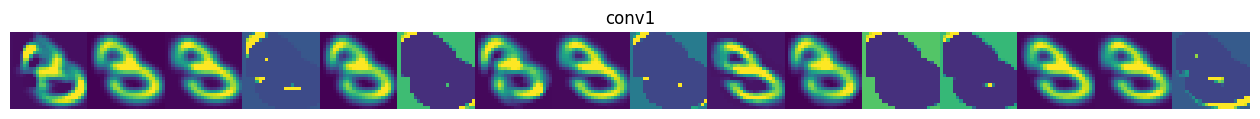

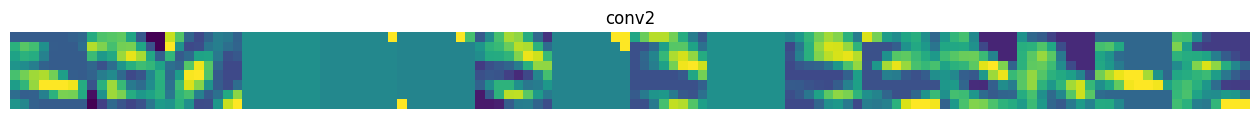

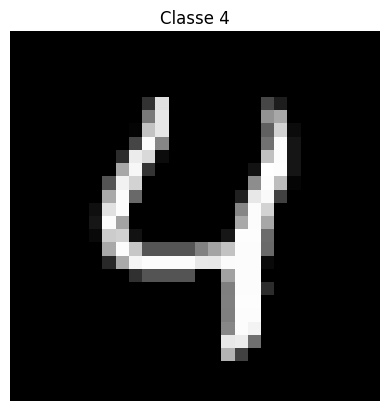

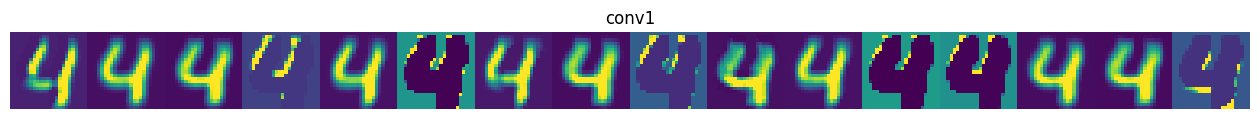

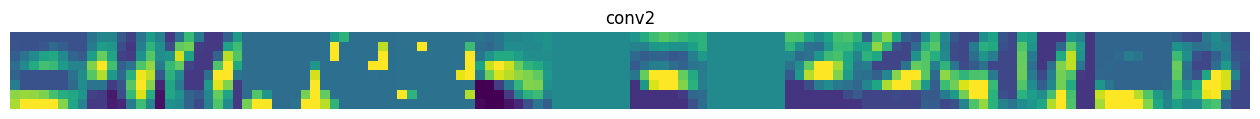

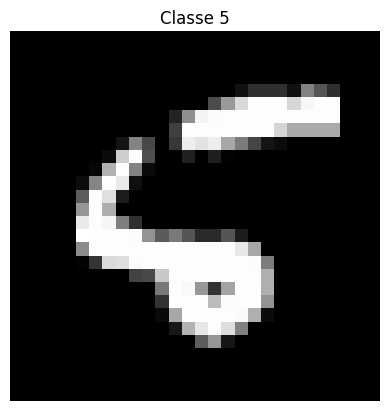

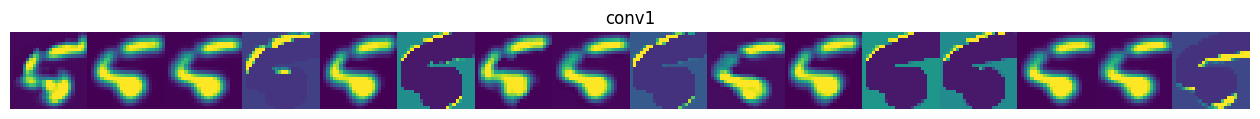

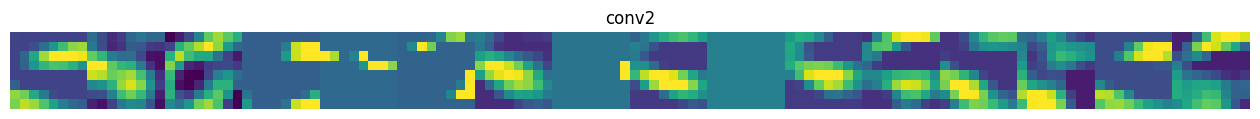

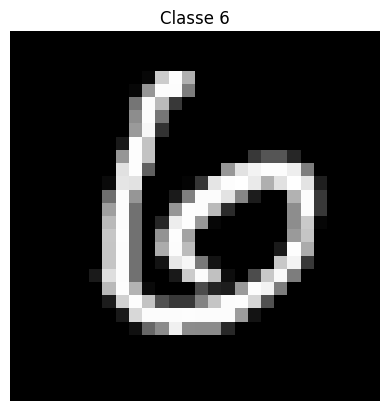

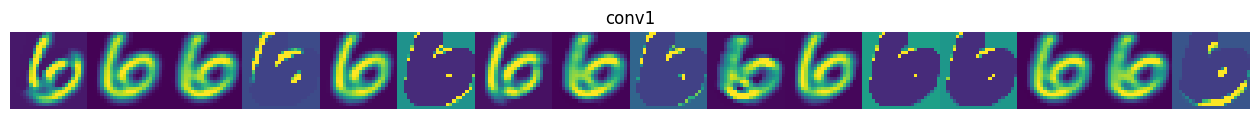

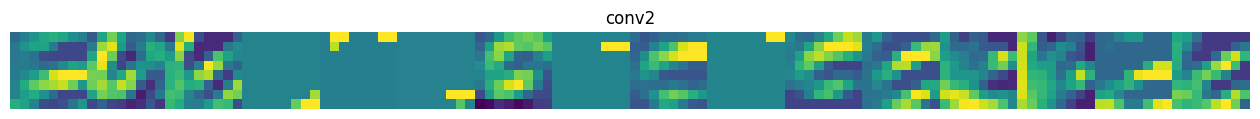

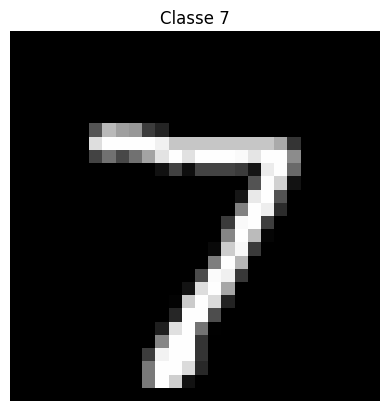

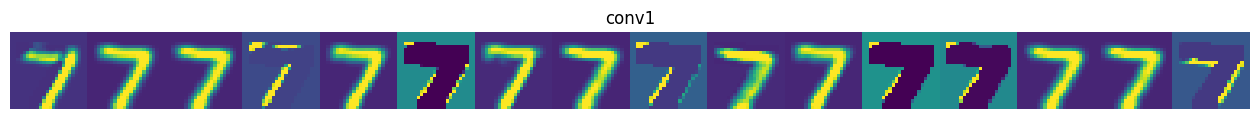

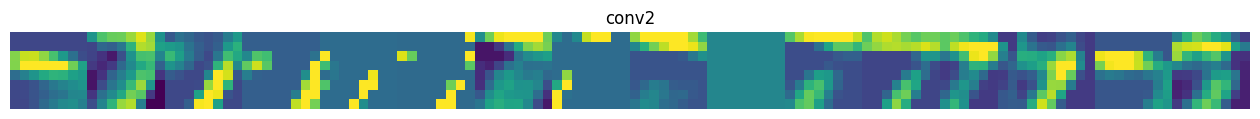

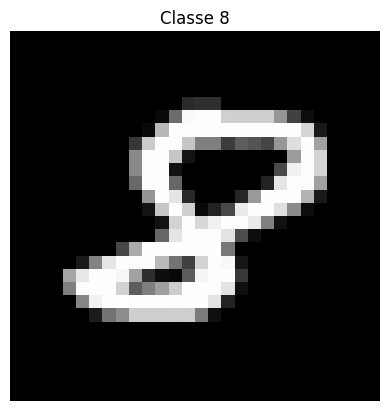

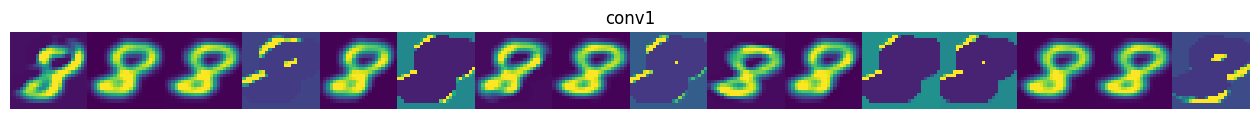

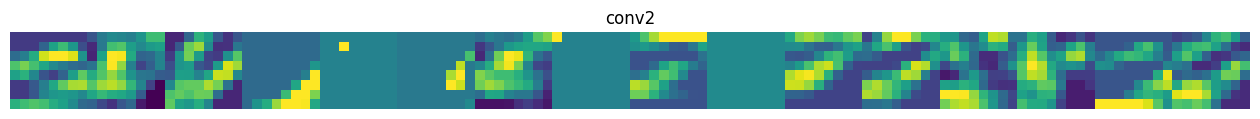

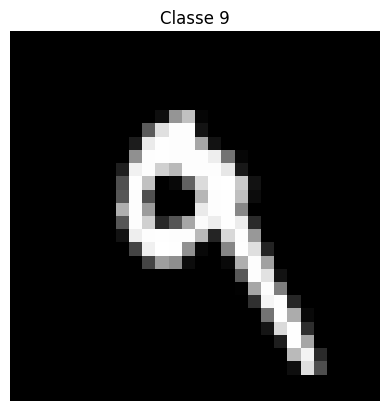

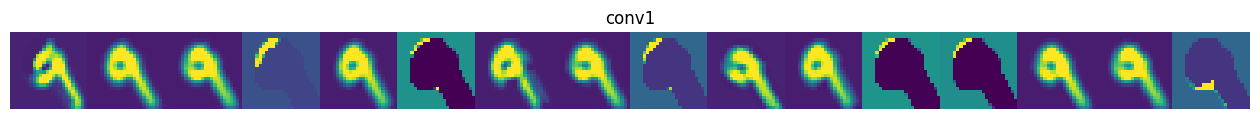

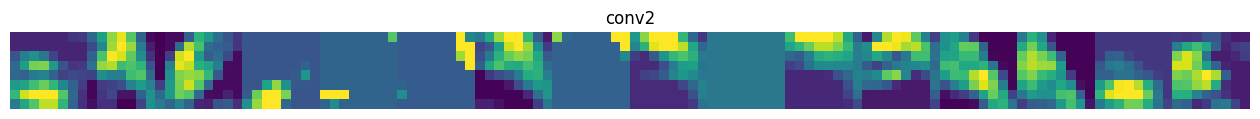

In [16]:
for i, cls in enumerate(classes):
    idx = np.where(y_test == cls)[0][0]

    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Classe {cls}")
    plt.axis('off')
    plt.show()

    img_preprocessed = preprocess_image(x_test[idx])
    feature_maps = activation_model.predict(img_preprocessed, verbose=False)

    layer_names = [layer.name for layer in model.layers if 'conv' in layer.name or 'expanded_conv' in layer.name]
    display_feature_maps(feature_maps, layer_names, max_layers=5, max_features=16)